In [1]:
import datetime

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['figure.figsize'] = (10, 7.5)
plt.rcParams['axes.grid'] = False

In [3]:
print(torch.__version__)

2.12.0


In [4]:
torch.manual_seed(42)
np.random.seed(42)

In [5]:
df = pd.read_csv('../data/metro_interstate_traffic_volume_preprocessed.csv')
df.head()

,date_time,temp,rain_1h,snow_1h,clouds_all,traffic_volume
0,2016-09-29 17:00:00,291.75,0.0,0.0,0.0,5551.0
1,2016-09-29 18:00:00,290.36,0.0,0.0,0.0,4132.0
2,2016-09-29 19:00:00,287.86,0.0,0.0,0.0,3435.0
3,2016-09-29 20:00:00,285.91,0.0,0.0,0.0,2765.0
4,2016-09-29 21:00:00,284.31,0.0,0.0,0.0,2443.0


In [6]:
df.tail()

,date_time,temp,rain_1h,snow_1h,clouds_all,traffic_volume
17546,2018-09-30 19:00:00,283.45,0.0,0.0,75.0,3543.0
17547,2018-09-30 20:00:00,282.76,0.0,0.0,90.0,2781.0
17548,2018-09-30 21:00:00,282.73,0.0,0.0,90.0,2159.0
17549,2018-09-30 22:00:00,282.09,0.0,0.0,90.0,1450.0
17550,2018-09-30 23:00:00,282.12,0.0,0.0,90.0,954.0


In [7]:
df.shape

(17551, 6)

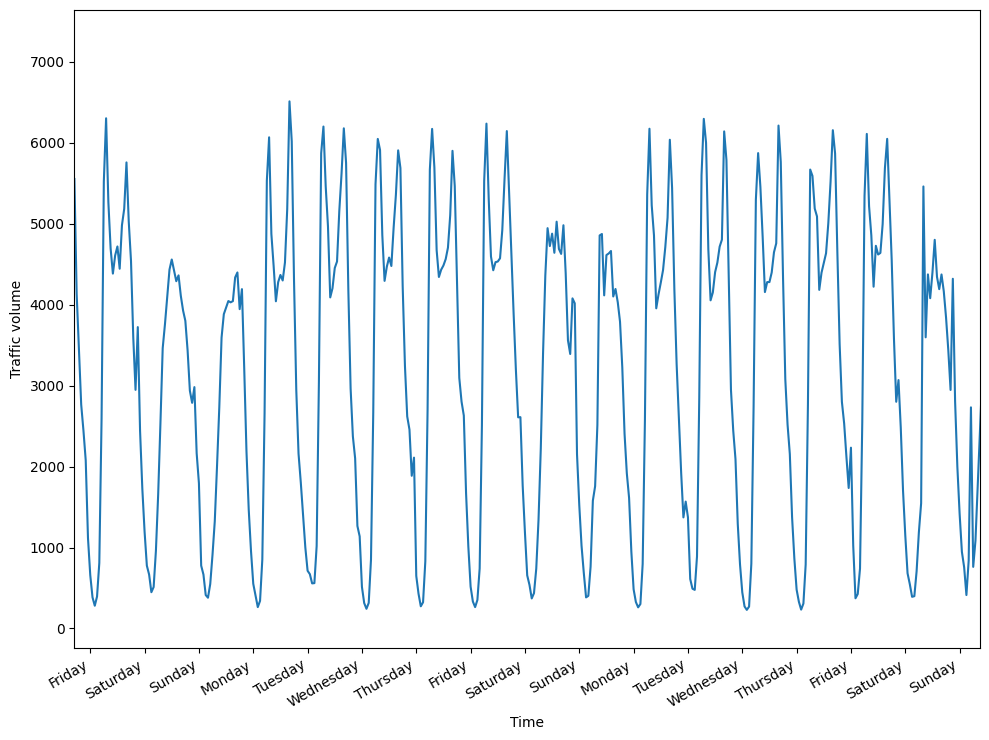

In [8]:
fig, ax = plt.subplots()

ax.plot(df['traffic_volume'])
ax.set_xlabel('Time')
ax.set_ylabel('Traffic volume')

plt.xticks(np.arange(7, 400, 24), ['Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.xlim(0, 400)

fig.autofmt_xdate()
plt.tight_layout()

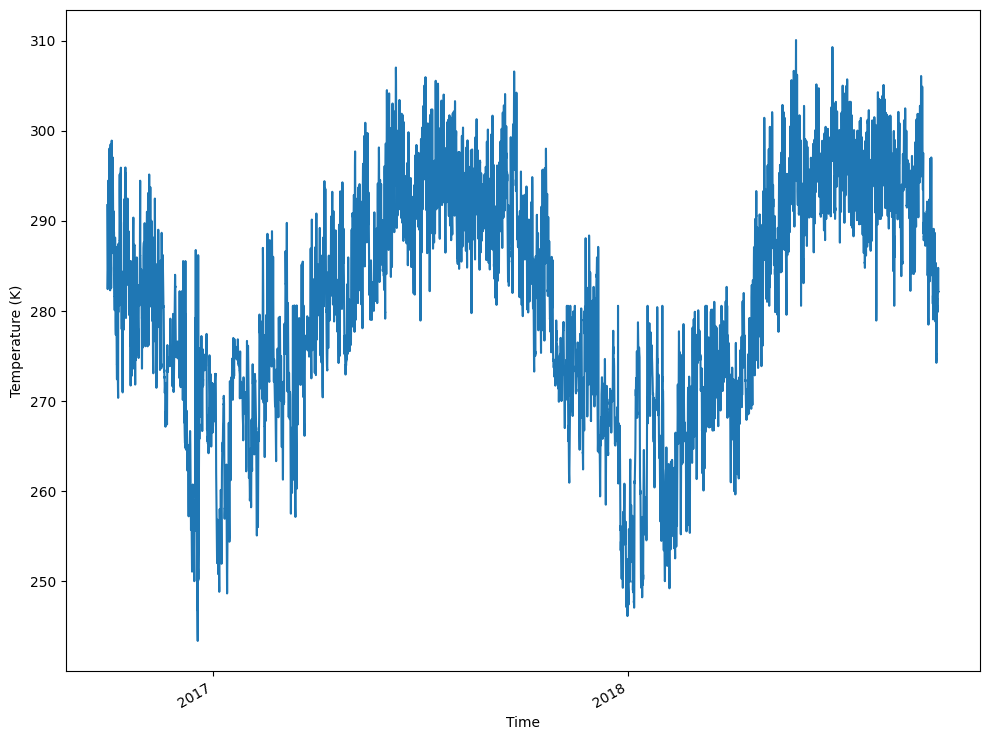

In [9]:
fig, ax = plt.subplots()

ax.plot(df['temp'])
ax.set_xlabel('Time')
ax.set_ylabel('Temperature (K)')

plt.xticks([2239, 10999], [2017, 2018])

fig.autofmt_xdate()
plt.tight_layout()

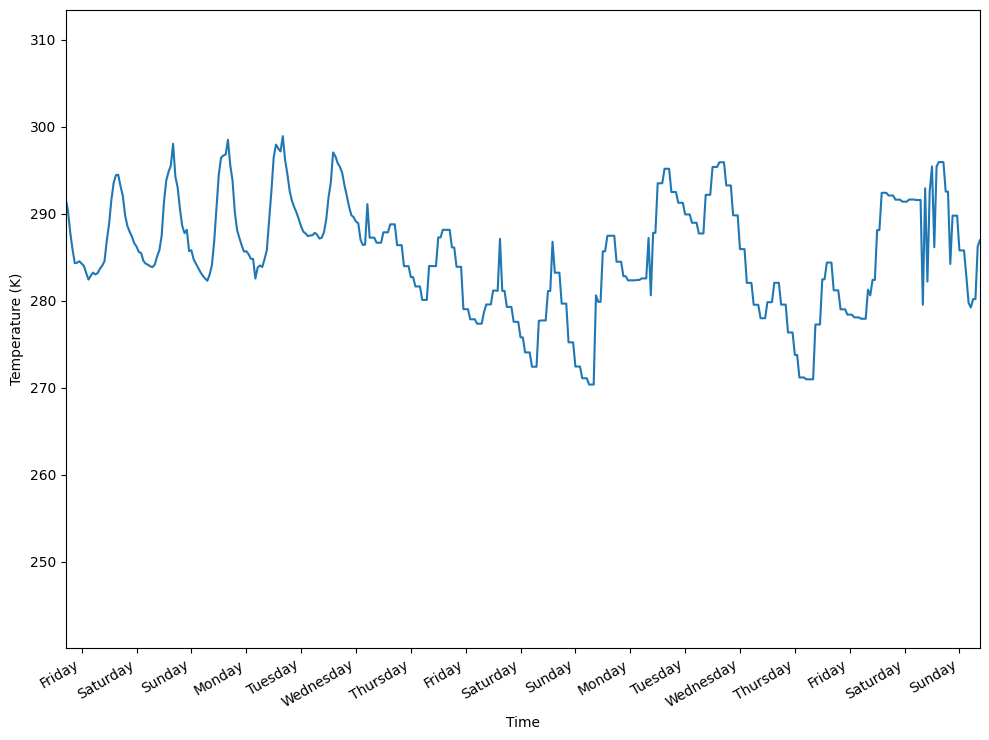

In [10]:
fig, ax = plt.subplots()

ax.plot(df['temp'])
ax.set_xlabel('Time')
ax.set_ylabel('Temperature (K)')

plt.xticks(np.arange(7, 400, 24), ['Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.xlim(0, 400)

fig.autofmt_xdate()
plt.tight_layout()

In [11]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
temp,17551.0,281.416203,12.688262,243.39,272.22,282.41,291.89,310.07
rain_1h,17551.0,0.025523,0.259794,0.00,0.00,0.00,0.00,10.60
snow_1h,17551.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
clouds_all,17551.0,42.034129,39.065960,0.00,1.00,40.00,90.00,100.00
traffic_volume,17551.0,3321.484588,1969.223949,113.00,1298.00,3518.00,4943.00,7280.00


In [12]:
cols_to_drop = ['rain_1h', 'snow_1h']
df = df.drop(cols_to_drop, axis=1)

df.shape

(17551, 4)

In [13]:
timestamp_s = pd.to_datetime(df['date_time']).map(datetime.datetime.timestamp)

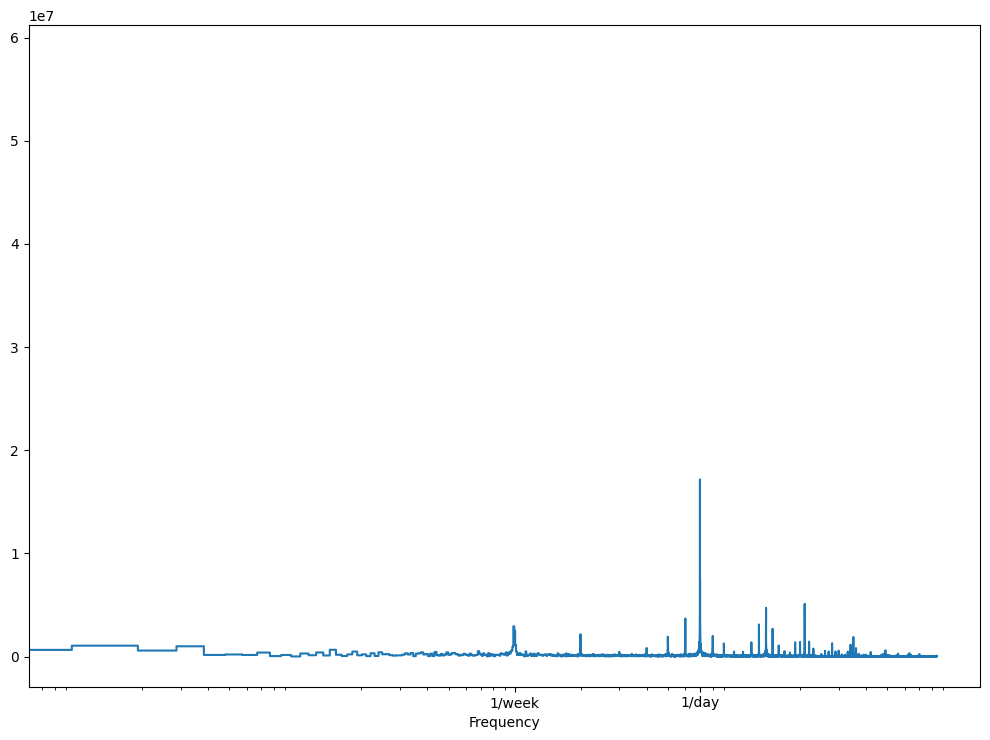

In [14]:
# 시계열을 PyTorch 텐서로 변환 (FFT 입력)
traffic_volume = torch.tensor(df['traffic_volume'].values, dtype=torch.float32)

# 실수값 FFT: 양의 주파수 성분만 계산 (길이 = n/2 + 1)
fft = torch.fft.rfft(traffic_volume)

# 주파수 빈(bin) 인덱스 (0, 1, 2, ...)
f_per_dataset = np.arange(0, len(fft))

# 시간 단위를 '주당 주기(cycles per week)'로 바꾸기 위한 준비
n_sample_h = len(df['traffic_volume'])  # 전체 시간 포인트 수 (시간 단위)
hours_per_week = 24 * 7
weeks_per_dataset = n_sample_h / hours_per_week  # 데이터가 몇 주 분량인지

# 빈 인덱스 → 주당 주파수로 변환 (x축 해석용)
f_per_week = f_per_dataset / weeks_per_dataset

# 스펙트럼 크기(magnitude)를 로그 x축으로 시각화
plt.step(f_per_week, np.abs(fft.numpy()))
plt.xscale('log')
plt.xticks([1, 7], ['1/week', '1/day'])  # 1 = 주 1회, 7 = 하루 1회 패턴
plt.xlabel('Frequency')
plt.tight_layout()

In [15]:
day = 24 * 60 * 60

df['day_sin'] = (np.sin(timestamp_s * (2*np.pi/day))).values
df['day_cos'] = (np.cos(timestamp_s * (2*np.pi/day))).values

In [16]:
df = df.drop(['date_time'], axis=1)

df.head()

,temp,clouds_all,traffic_volume,day_sin,day_cos
0,291.75,0.0,5551.0,8.660254e-01,-0.500000
1,290.36,0.0,4132.0,7.071068e-01,-0.707107
2,287.86,0.0,3435.0,5.000000e-01,-0.866025
3,285.91,0.0,2765.0,2.588190e-01,-0.965926
4,284.31,0.0,2443.0,1.485292e-12,-1.000000


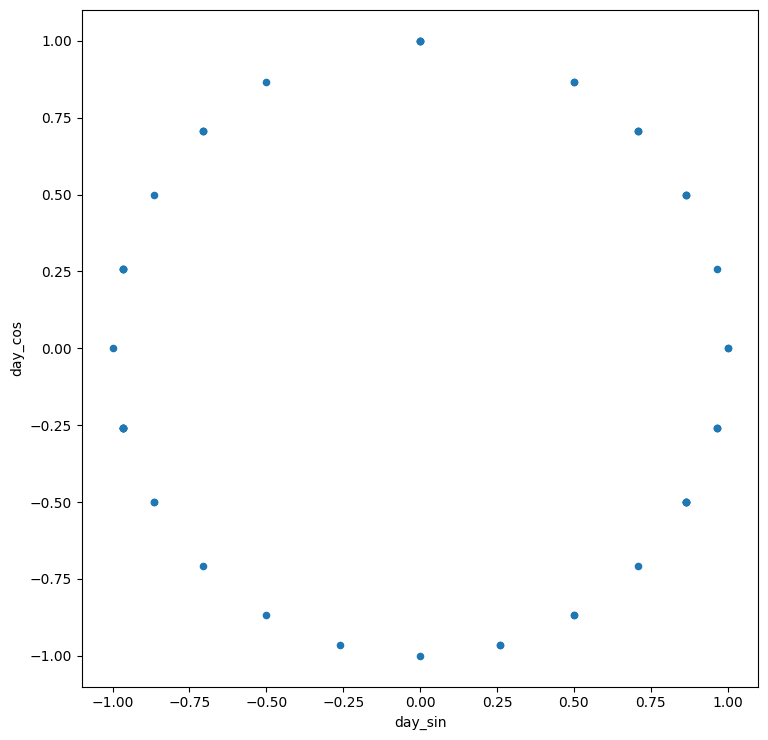

In [17]:
df.sample(50).plot.scatter('day_sin','day_cos').set_aspect('equal')
plt.tight_layout()

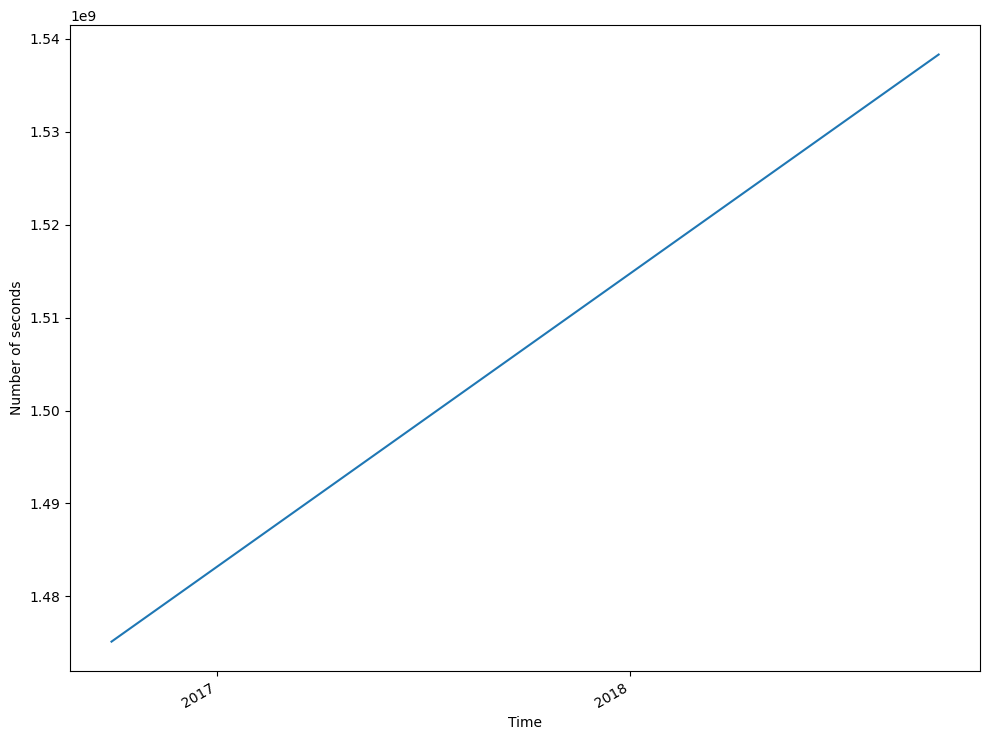

In [18]:
fig, ax = plt.subplots()

ax.plot(timestamp_s)
ax.set_xlabel('Time')
ax.set_ylabel('Number of seconds')

plt.xticks([2239, 10999], [2017, 2018])

fig.autofmt_xdate()
plt.tight_layout()

In [19]:
n = len(df)

# Split 70:20:10 (train:validation:test)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

train_df.shape, val_df.shape, test_df.shape

((12285, 5), (3510, 5), (1756, 5))

In [20]:
scaler = MinMaxScaler()
scaler.fit(train_df)

train_df[train_df.columns] = scaler.transform(train_df[train_df.columns])
val_df[val_df.columns] = scaler.transform(val_df[val_df.columns])
test_df[test_df.columns] = scaler.transform(test_df[test_df.columns])

In [21]:
train_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
temp,12285.0,0.555681,0.196527,0.0,0.424800,0.557913,0.715072,1.0
clouds_all,12285.0,0.431034,0.393716,0.0,0.010000,0.400000,0.900000,1.0
traffic_volume,12285.0,0.445735,0.273635,0.0,0.165899,0.473141,0.671271,1.0
day_sin,12285.0,0.499881,0.353528,0.0,0.146447,0.500000,0.853553,1.0
day_cos,12285.0,0.500000,0.353607,0.0,0.146447,0.500000,0.853553,1.0


In [22]:
train_df.to_csv('../data/train.csv')
val_df.to_csv('../data/val.csv')
test_df.to_csv('../data/test.csv')

In [23]:
test_df

,temp,clouds_all,traffic_volume,day_sin,day_cos
15795,0.767405,0.90,0.401563,0.629410,0.017037
15796,0.756876,0.90,0.348821,0.500000,0.000000
15797,0.754833,0.90,0.302637,0.370590,0.017037
15798,0.754833,0.90,0.187108,0.250000,0.066987
15799,0.756247,0.90,0.080926,0.146447,0.146447
...,...,...,...,...,...
17546,0.629577,0.75,0.478582,0.750000,0.066987
17547,0.618733,0.90,0.372262,0.629410,0.017037
17548,0.618262,0.90,0.285475,0.500000,0.000000
17549,0.608204,0.90,0.186549,0.370590,0.017037
